In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('bengaluru_house_prices.csv')

In [3]:
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib 
matplotlib.rcParams["figure.figsize"] = (20,10)

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## DATA PRE PROCESSING

In [5]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Missing values
print("\nMissing values:")
print(df.isna().sum())

# Basic statistics
df.describe(include='all')

#Basic outlier check (for information)
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

print("\nOutlier counts (IQR method):")
for col in numeric_cols:
    print(f"{col}: {count_outliers_iqr(df[col].dropna())} outliers")


Shape: (13320, 9)

Data types:
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

Numeric columns: ['bath', 'balcony', 'price']
Categorical columns: ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft']

Missing values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Outlier counts (IQR method):
bath: 1039 outliers
balcony: 0 outliers
price: 1276 outliers


## EDA

In [6]:
df['area_type'].unique()


array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [7]:
df['area_type'].value_counts()


area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [8]:
5502*100/13320
## CHECKING MISSING VALUES FOR SOCIETY COLUMN

41.306306306306304

In [9]:
df2 = df.dropna()
df2.drop(['society','availability'],axis='columns')
df2.isnull().sum()
# DROPPING

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

#### FEATURE ENGINEERING


In [10]:
df2['bhk'] = df2['size'].apply(lambda x: int(x.split(' ')[0]))
df2.bhk.unique()

C:\Users\A\AppData\Local\Temp\ipykernel_21680\4049590364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['bhk'] = df2['size'].apply(lambda x: int(x.split(' ')[0]))


array([ 2,  4,  3,  1,  5, 11,  9,  6,  7])

In [11]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [12]:
df2[~df2['total_sqft'].apply(is_float)].head(10)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,19-Dec,Yelahanka,4 BHK,LedorSa,2100 - 2850,4.0,0.0,186.000,4
122,Super built-up Area,18-Mar,Hebbal,4 BHK,SNontle,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,19-Mar,8th Phase JP Nagar,2 BHK,Vaarech,1042 - 1105,2.0,0.0,54.005,2
165,Super built-up Area,18-Dec,Sarjapur,2 BHK,Kinuerg,1145 - 1340,2.0,0.0,43.490,2
188,Super built-up Area,Ready To Move,KR Puram,2 BHK,MCvarar,1015 - 1540,2.0,0.0,56.800,2
549,Super built-up Area,18-Sep,Hennur Road,2 BHK,Shxorm,1195 - 1440,2.0,0.0,63.770,2
661,Super built-up Area,Ready To Move,Yelahanka,2 BHK,Rarthne,1120 - 1145,2.0,0.0,48.130,2
672,Built-up Area,18-Mar,Bettahalsoor,4 Bedroom,Toainnt,3090 - 5002,4.0,0.0,445.000,4
772,Super built-up Area,20-Dec,Banashankari Stage VI,2 BHK,Brens7,1160 - 1195,2.0,0.0,59.935,2
850,Super built-up Area,22-Dec,Bannerghatta Road,2 BHK,PrarePa,1115 - 1130,2.0,0.0,58.935,2


##### ABOVE DATA SHOWS THAT TOTAL SQFT CAN BE A RANGE (E.G. 2100-2850). FOR SUCH CASES WE CAN JUST TAKE AVERAGE OF MIN & MAX VALUE IN THE RANGE. THERE ARE OTHER CASES WHERE VALUES ARE IN SQM WHICH CAN BE CONVERTED TO SQFT USING UNIT CONVERSION.

In [13]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None   

In [14]:
df4 = df2.copy()
df4.total_sqft = df4.total_sqft.apply(convert_sqft_to_num)
df4 = df4[df4.total_sqft.notnull()]
df4.head(2)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4


#### ADD NEW FEATURE CALLED PRICE PER SQUARE FEET


In [15]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.384615
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.890861
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170.0,2.0,1.0,38.00,2,3247.863248
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785.0,5.0,3.0,295.00,4,10592.459605


In [16]:
df5_stats = df5['price_per_sqft'].describe()
df5_stats

count      7481.000000
mean       5992.058235
std        9160.840277
min         371.428571
25%        4279.131007
50%        5319.148936
75%        6696.629213
max      672727.272727
Name: price_per_sqft, dtype: float64

In [17]:
df5.to_csv("bhp2.csv",index=False)

##### EXAMINE LOCATIONS WHICH IS A CATEGORICAL VARIABLE. WE NEED TO APPLY THE DIMENSIONALITY REDUCTION TECHNIQUE HERE TO REDUCE THE NUMBER OF LOCATIONS


In [18]:
df5.location = df5.location.apply(lambda x: x.strip())
location_stats = df5['location'].value_counts(ascending=False)
location_stats

location
Whitefield                    397
Sarjapur  Road                310
Electronic City               238
Kanakpura Road                216
Thanisandra                   214
                             ... 
Church Street                   1
Sarvobhogam Nagar               1
Near International Airport      1
Palace Road                     1
Abshot Layout                   1
Name: count, Length: 625, dtype: int64

In [19]:
location_stats.values.sum()

np.int64(7481)

In [20]:
len(location_stats[location_stats>10])

143

In [21]:
len(location_stats)

625

In [22]:
len(location_stats[location_stats<=10])


482

### DIMENSIONALITY REDUCTIONS 

In [23]:
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10

location
Sector 2 HSR Layout           10
Banashankari Stage III        10
Vidyaranyapura                10
BTM Layout                    10
Dairy Circle                  10
                              ..
Church Street                  1
Sarvobhogam Nagar              1
Near International Airport     1
Palace Road                    1
Abshot Layout                  1
Name: count, Length: 482, dtype: int64

In [24]:
len(df5.location.unique())


625

In [25]:
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df5.location.unique())

144

In [26]:
df5.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.384615
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.890861
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170.0,2.0,1.0,38.00,2,3247.863248
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785.0,5.0,3.0,295.00,4,10592.459605
12,Super built-up Area,Ready To Move,7th Phase JP Nagar,2 BHK,Shncyes,1000.0,2.0,1.0,38.00,2,3800.000000
14,Plot Area,Ready To Move,Sarjapur,3 Bedroom,Skityer,2250.0,3.0,2.0,148.00,3,6577.777778
15,Super built-up Area,Ready To Move,Mysore Road,2 BHK,PrntaEn,1175.0,2.0,2.0,73.50,2,6255.319149
16,Super built-up Area,Ready To Move,Bisuvanahalli,3 BHK,Prityel,1180.0,3.0,2.0,48.00,3,4067.796610
17,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,3 BHK,GrrvaGr,1540.0,3.0,3.0,60.00,3,3896.103896


### OUTLIER REMOVAL 

In [27]:
df5[df5.total_sqft/df5.bhk<300].head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
349,Plot Area,18-Dec,other,3 Bedroom,PrhyaK,11.0,3.0,2.0,74.0,3,672727.272727
480,Built-up Area,Ready To Move,other,4 BHK,LiaveEn,1150.0,4.0,2.0,260.0,4,22608.695652
483,Plot Area,Ready To Move,other,5 Bedroom,Bemesrm,1200.0,5.0,2.0,190.0,5,15833.333333
1239,Built-up Area,Ready To Move,Electronic City,2 BHK,Itelaa,550.0,1.0,1.0,16.0,2,2909.090909
2040,Super built-up Area,Ready To Move,Electronic City,2 BHK,Itelaa,550.0,1.0,1.0,15.0,2,2727.272727


In [28]:
df5.shape


(7481, 11)

In [29]:
df6 = df5[~(df5.total_sqft/df5.bhk<300)]
df6.shape

(7439, 11)

##### OUTLIER REMOVAL USING STANDARD DEVIATION AND MEAN


In [30]:
df6.price_per_sqft.describe()


count     7439.000000
mean      5851.020195
std       2705.465697
min        371.428571
25%       4283.397683
50%       5319.284802
75%       6693.881632
max      76530.612245
Name: price_per_sqft, dtype: float64

In [31]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df7 = remove_pps_outliers(df6)
df7.shape

(5862, 11)

#### WE SHOULD ALSO REMOVE PROPERTIES WHERE FOR THE SAME LOCATION, THE PRICE OF (FOR EXAMPLE) A 3 BEDROOM APARTMENT IS LESS THAN A 2 BEDROOM APARTMENT (WITH THE SAME SQUARE FT AREA). WHAT WE WILL DO IS FOR A GIVEN LOCATION, WE WILL BUILD A DICTIONARY OF STATS PER BHK, I.E.




In [32]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')
df8 = remove_bhk_outliers(df7)

df8.shape

(4059, 11)

In [33]:
df8.bath.unique()


array([4., 3., 2., 5., 1., 6., 7., 9.])

In [34]:
df8[df8.bath>10]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft


In [35]:
df8[df8.bath>df8.bhk+2]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
3791,Super built-up Area,Ready To Move,Thanisandra,3 BHK,Soitya,1806.0,6.0,2.0,116.0,3,6423.034330
4866,Super built-up Area,Ready To Move,other,6 BHK,Prowshi,11338.0,9.0,1.0,1000.0,6,8819.897689


In [36]:
df9 = df8[df8.bath<df8.bhk+2]
df9.shape

(4017, 11)

In [37]:
df9.head(2)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,4 BHK,Prhtsok,2825.0,4.0,3.0,250.0,4,8849.557522
1,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,Prhtsok,1875.0,3.0,1.0,167.0,3,8906.666667


In [38]:
df10 = df9.drop(['size','price_per_sqft'],axis='columns')
df10.head(3)

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,Prhtsok,2825.0,4.0,3.0,250.0,4
1,Super built-up Area,Ready To Move,1st Phase JP Nagar,Prhtsok,1875.0,3.0,1.0,167.0,3
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,NCaveun,1394.0,2.0,1.0,100.0,2


### USE ONE HOT ENCODING FOR LOCATION


In [39]:
dummies = pd.get_dummies(df10.location)
dummies.head(3)

,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,Abbigere,Akshaya Nagar,Ambalipura,Ambedkar Nagar,...,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur,other
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
df11 = pd.concat([df10,dummies.drop('other',axis='columns')],axis='columns')
df11.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk,1st Phase JP Nagar,...,Thubarahalli,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,Prhtsok,2825.0,4.0,3.0,250.0,4,True,...,False,False,False,False,False,False,False,False,False,False
1,Super built-up Area,Ready To Move,1st Phase JP Nagar,Prhtsok,1875.0,3.0,1.0,167.0,3,True,...,False,False,False,False,False,False,False,False,False,False
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,NCaveun,1394.0,2.0,1.0,100.0,2,True,...,False,False,False,False,False,False,False,False,False,False
3,Super built-up Area,18-May,1st Phase JP Nagar,Inntsth,1077.0,2.0,2.0,93.0,2,True,...,False,False,False,False,False,False,False,False,False,False
4,Super built-up Area,18-May,1st Phase JP Nagar,Inntsth,1590.0,3.0,3.0,131.0,3,True,...,False,False,False,False,False,False,False,False,False,False


In [41]:
df12 = df11.drop(['location','society','availability'],axis='columns')
df12.head(2)

,area_type,total_sqft,bath,balcony,price,bhk,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Thubarahalli,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,Super built-up Area,2825.0,4.0,3.0,250.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Super built-up Area,1875.0,3.0,1.0,167.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## LABEL ENCODER FOR AREA TYPE COLUMN

In [42]:
from sklearn.preprocessing import LabelEncoder

# create label encoder object
le = LabelEncoder()

# apply label encoding
df12['area_type'] = le.fit_transform(df12['area_type'])


df12.head(2)

,area_type,total_sqft,bath,balcony,price,bhk,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Thubarahalli,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,3,2825.0,4.0,3.0,250.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3,1875.0,3.0,1.0,167.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Univariate Analysis

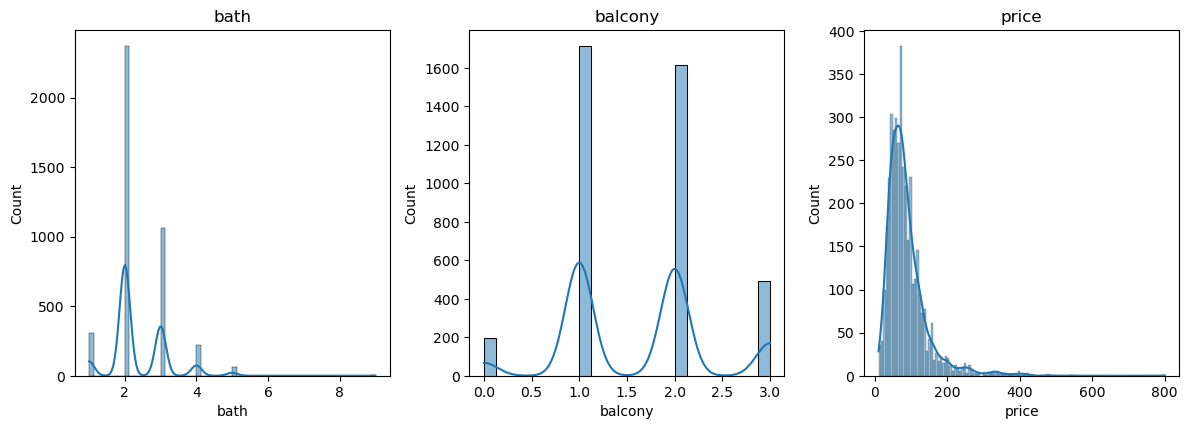

In [43]:
# Histograms for numeric variables
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df12[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

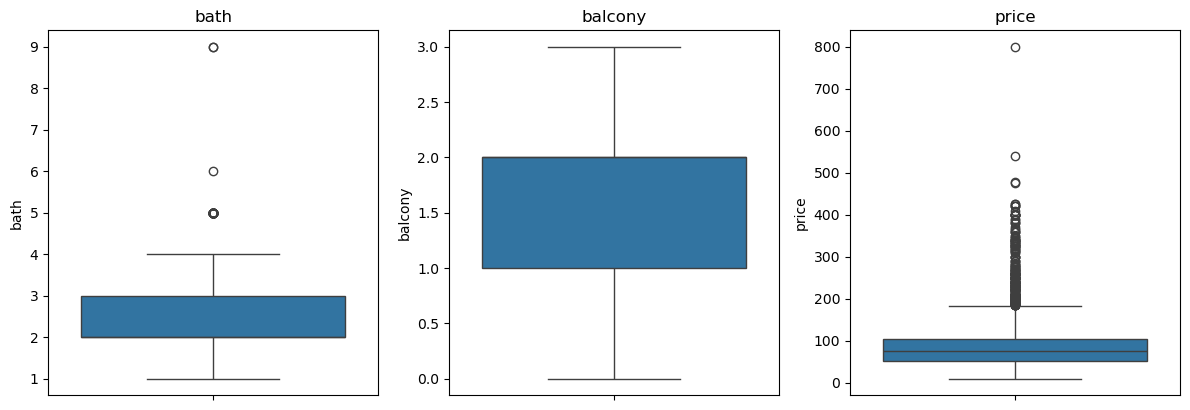

In [44]:
# Boxplots to spot outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df12[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [45]:
Q1 = df12['price'].quantile(0.25)
Q3 = df12['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [46]:
# Identify outliers
price_outliers = df12[
    (df12['price'] < lower_bound) |
    (df12['price'] > upper_bound)
]

# View outlier rows
price_outliers


,area_type,total_sqft,bath,balcony,price,bhk,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Thubarahalli,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,3,2825.0,4.0,3.0,250.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,3,2180.0,3.0,2.0,210.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,3,2615.0,5.0,3.0,222.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
34,3,2503.0,4.0,0.0,188.0,4,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
188,0,3530.0,4.0,2.0,290.0,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5631,0,3200.0,4.0,0.0,270.0,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5637,2,4395.0,3.0,3.0,240.0,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5721,2,2400.0,3.0,0.0,200.0,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5731,3,2360.0,3.0,2.0,185.0,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [47]:
# Key statistics + skewness
stats_summary = df12[numeric_cols].agg(['mean', 'median']).T
stats_summary['skewness'] = df12[numeric_cols].skew()
stats_summary

,mean,median,skewness
bath,2.348021,2.0,1.183703
balcony,1.599203,2.0,0.162951
price,87.508201,75.0,2.802987


In [48]:
df12.head()

,area_type,total_sqft,bath,balcony,price,bhk,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Thubarahalli,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,3,2825.0,4.0,3.0,250.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3,1875.0,3.0,1.0,167.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1394.0,2.0,1.0,100.0,2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,1077.0,2.0,2.0,93.0,2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3,1590.0,3.0,3.0,131.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Bivariate Analysis

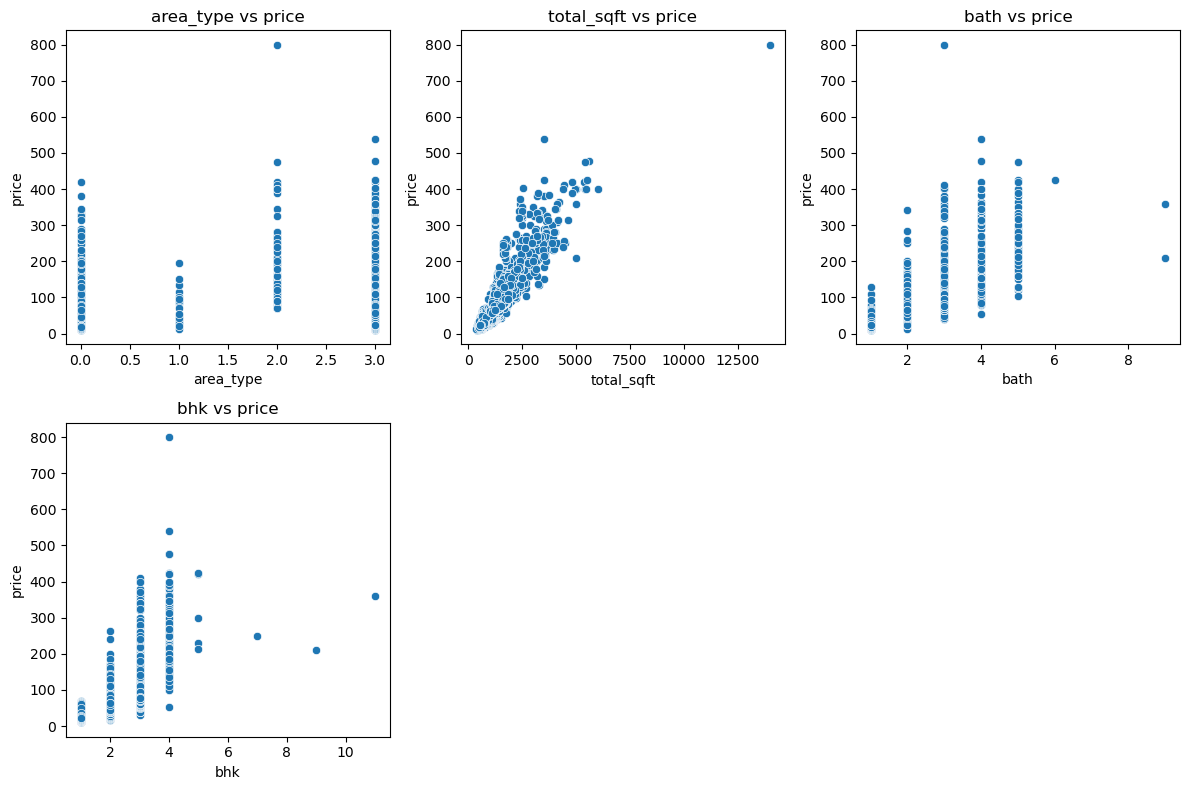

In [49]:
# Final modeling dataframe
features = ['area_type', 'total_sqft', 'bath','bhk']
target = 'price'
plt.figure(figsize=(12, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df12[col], y=df12[target])
    plt.title(f'{col} vs {target}')
plt.tight_layout()
plt.show()

In [50]:
df12.shape

(4017, 149)

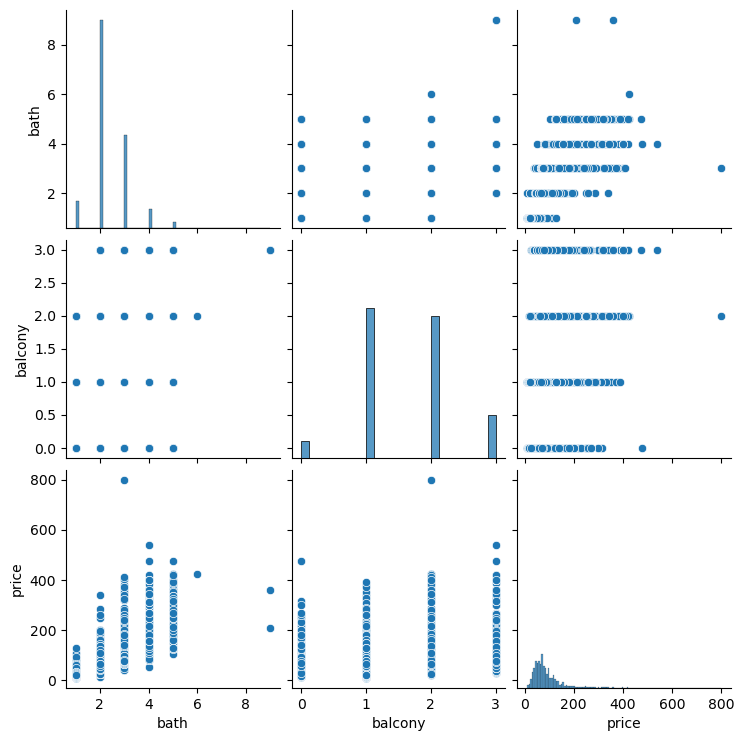

In [51]:
sns.pairplot(df12[numeric_cols])
plt.show()

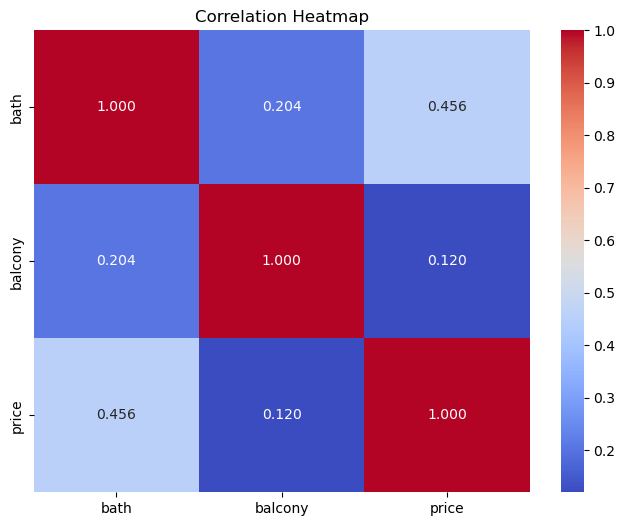

,bath,balcony,price
bath,1.000000,0.204201,0.456345
balcony,0.204201,1.000000,0.120355
price,0.456345,0.120355,1.000000


In [52]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

corr

In [53]:
df13 = df12.drop(['balcony'],axis='columns')
df13.head(3)

,area_type,total_sqft,bath,price,bhk,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Thubarahalli,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,3,2825.0,4.0,250.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3,1875.0,3.0,167.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1394.0,2.0,100.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [54]:
# Step 1: Remove extreme outliers using IQR
Q1 = df13['price'].quantile(0.25)
Q3 = df13['price'].quantile(0.75)
IQR = Q3 - Q1

df13 = df13[
    (df13['price'] >= Q1 - 1.5 * IQR) &
    (df13['price'] <= Q3 + 1.5 * IQR)
]

# Step 2: Log transform price
df13['log_price'] = np.log1p(df13['price'])


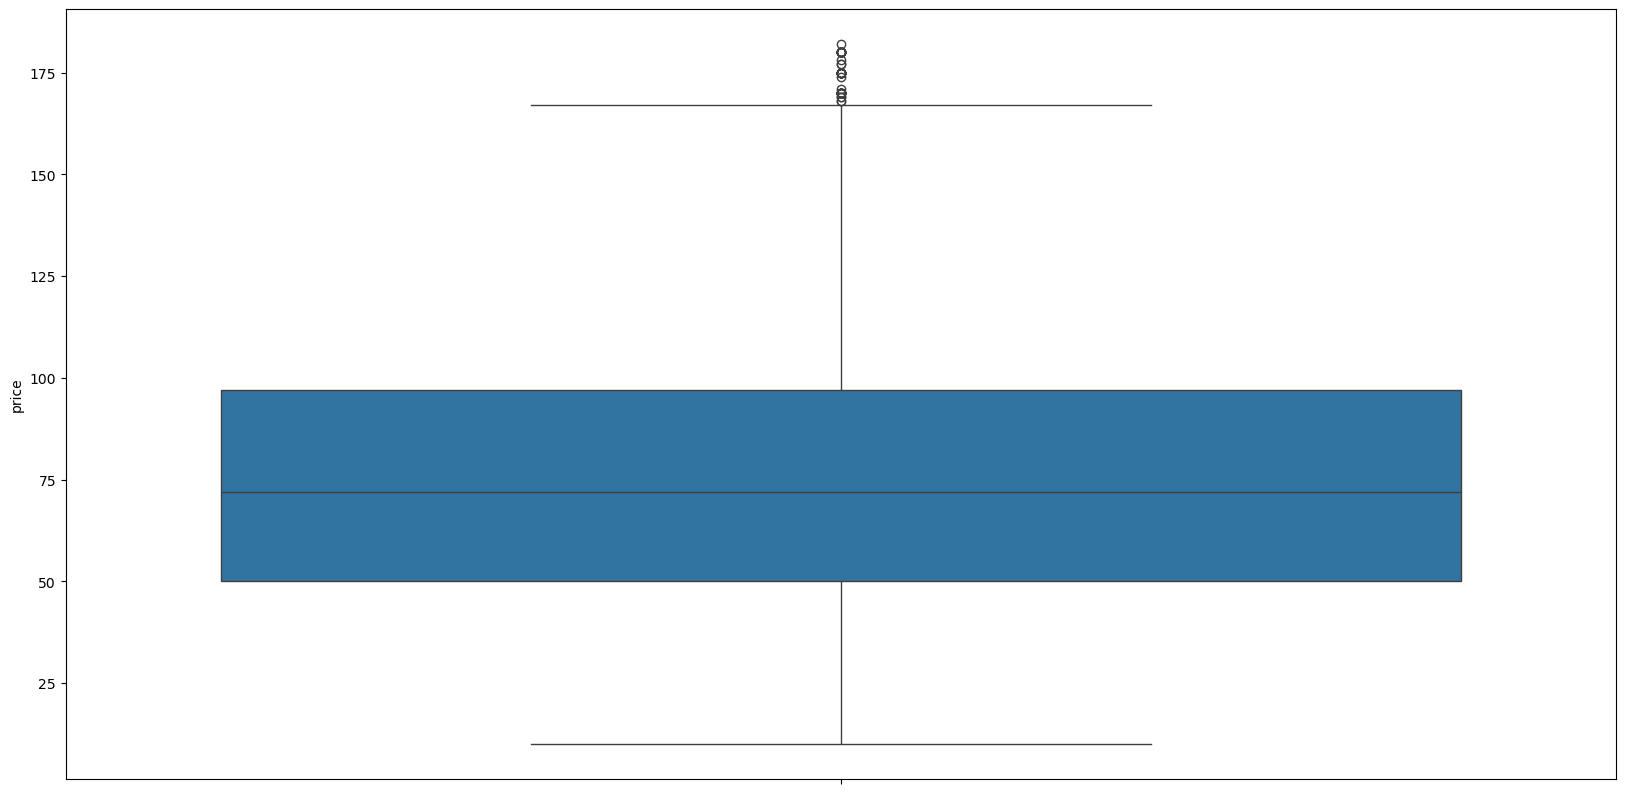

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df13['price'])
plt.show()


In [56]:
# Key statistics + skewness
stats_summary = df13['price'].agg(['mean', 'median']).T
stats_summary['skewness'] = df13['price'].skew()
stats_summary

mean        76.868879
median      72.000000
skewness     0.704198
Name: price, dtype: float64

# BUILDING A MODEL

In [71]:
X = df13.drop(['price'],axis='columns')
X.head(3)

,area_type,total_sqft,bath,bhk,1st Phase JP Nagar,5th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,...,Tumkur Road,Uttarahalli,Varthur,Vijayanagar,Vittasandra,Whitefield,Yelahanka,Yelahanka New Town,Yeshwanthpur,log_price
1,3,1875.0,3.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,5.123964
2,3,1394.0,2.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,4.615121
3,3,1077.0,2.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,4.543295


In [72]:
X.shape

(3787, 148)

In [73]:
y = df13.price
y.head(3)

1    167.0
2    100.0
3     93.0
Name: price, dtype: float64

In [74]:
len(y)

3787

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)



In [77]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)
y_pred = lr_clf.predict(X_test)

In [78]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE:", rmse)


R² Score: 0.9509682375848809
RMSE: 7.807768806397452


In [79]:
# Convert log prices back to actual prices
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

# Define threshold (median price)
threshold = y_test_actual.median()

# True labels
y_test_class = (y_test_actual >= threshold).astype(int)

# Predicted labels
y_pred_class = (y_pred_actual >= threshold).astype(int)


In [81]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_class, y_pred_class)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[327  52]
 [  1 378]]


In [84]:
from sklearn.metrics import accuracy_score , precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall    = recall_score(y_test_class, y_pred_class)
f1        = f1_score(y_test_class, y_pred_class)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Accuracy  : 0.9301
Precision : 0.8791
Recall    : 0.9974
F1 Score  : 0.9345


## APPLY NET ELASTIC REGRESSION

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error


In [86]:
# Target
y = df13['price']

# Features (drop target + original price)
X = df13.drop(columns=['price'])


In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [88]:
elastic_net = ElasticNet(
    alpha=0.1,        # regularization strength
    l1_ratio=0.5,     # 0 = Ridge, 1 = Lasso, between = Elastic Net
    random_state=42)

elastic_net.fit(X_train_scaled, y_train)


ElasticNet(alpha=0.1, random_state=42)

In [89]:
y_pred = elastic_net.predict(X_test_scaled)


In [90]:
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("RMSE:", rmse)


R² Score: 0.9494513090510894
RMSE: 59.876701402592936


In [91]:
coefficients = pd.Series(
    elastic_net.coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

coefficients.head(10)


log_price                20.793572
total_sqft               11.177727
bath                      1.677914
Hebbal Kempapura          1.596683
Raja Rajeshwari Nagar    -1.554447
bhk                      -1.550092
Attibele                  1.514001
Koramangala               1.497627
Rajaji Nagar              1.440125
Begur Road               -1.134412
dtype: float64

#### USE K FOLD CROSS VALIDATION TO MEASURE ACCURACY OF OUR LINEAR REGRESSION MODEL

In [92]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.95316328, 0.95320679, 0.95050937, 0.95319655, 0.95488273])

In [93]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(ElasticNet(), X, y, cv=cv)

array([0.78641294, 0.77756549, 0.81044349, 0.75212377, 0.80520108])

In [94]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np


In [95]:
# Convert log prices back to actual prices
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

# Define threshold (median price)
threshold = y_test_actual.median()

# True labels
y_test_class = (y_test_actual >= threshold).astype(int)

# Predicted labels
y_pred_class = (y_pred_actual >= threshold).astype(int)


In [96]:
cm = confusion_matrix(y_test_class, y_pred_class)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[330  46]
 [  5 377]]


In [97]:
accuracy  = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall    = recall_score(y_test_class, y_pred_class)
f1        = f1_score(y_test_class, y_pred_class)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Accuracy  : 0.9327
Precision : 0.8913
Recall    : 0.9869
F1 Score  : 0.9366


In [98]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df


,Metric,Value
0,Accuracy,0.932718
1,Precision,0.891253
2,Recall,0.986911
3,F1 Score,0.936646
